In [1]:
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv('data/spotify.csv')

df

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,India,33,2022-09-23,Free,Active,2,0,Yes,No,5,11.83,Latin,Offline Mode,Concert Alerts,Tablet,8,5
49996,49997,Italy,35,2023-11-17,Premium Family,Active,0,0,No,No,4,8.01,Latin,Podcasts,Mood-based Auto Playlists,Car System,11,10
49997,49998,Brazil,33,2024-11-14,Premium Individual,Active,0,0,No,No,2,14.47,Rock,Lyrics,Lyrics Translation,Smart Speaker,9,13
49998,49999,USA,43,2021-05-31,Free,Active,0,0,No,No,5,21.86,Indie,AI DJ,Social Listening,Mobile,9,12


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  str    
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  str    
 4   subscription_type               50000 non-null  str    
 5   subscription_status             50000 non-null  str    
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  str    
 9   ad_conversion_to_subscription   50000 non-null  str    
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  50000 non-n

In [3]:
df.isnull().sum()

user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

In [4]:
df.describe()

,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

df['subscription_status'] = (df['subscription_status'] == 'Active').astype(int)
df['ad_interaction'] = (df['ad_interaction'] == 'Yes').astype(int)
df['ad_conversion_to_subscription'] = (df['ad_conversion_to_subscription'] == 'Yes').astype(int)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         50000 non-null  int64         
 1   country                         50000 non-null  str           
 2   age                             50000 non-null  int64         
 3   signup_date                     50000 non-null  datetime64[us]
 4   subscription_type               50000 non-null  str           
 5   subscription_status             50000 non-null  int64         
 6   months_inactive                 50000 non-null  int64         
 7   inactive_3_months_flag          50000 non-null  int64         
 8   ad_interaction                  50000 non-null  int64         
 9   ad_conversion_to_subscription   50000 non-null  int64         
 10  music_suggestion_rating_1_to_5  50000 non-null  int64         
 11  avg_listening

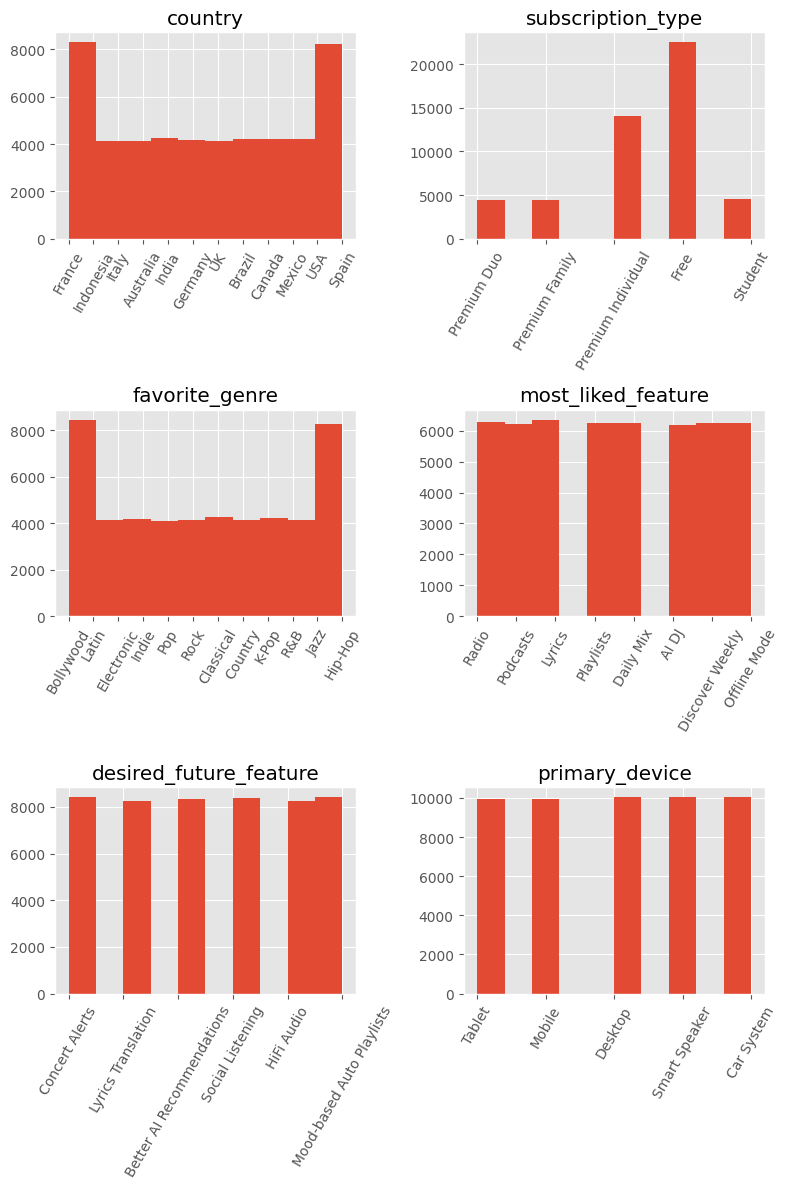

In [27]:
str_cols = df.select_dtypes(include=['object', 'str']).columns

plt.figure(figsize= (8,12))



for count, col in enumerate(str_cols):
    plt.subplot(int(len(str_cols) // 2), 2, count + 1)
    df[col].hist()
    plt.xticks(rotation = 60)
    plt.title(col)

plt.tight_layout()
plt.show()

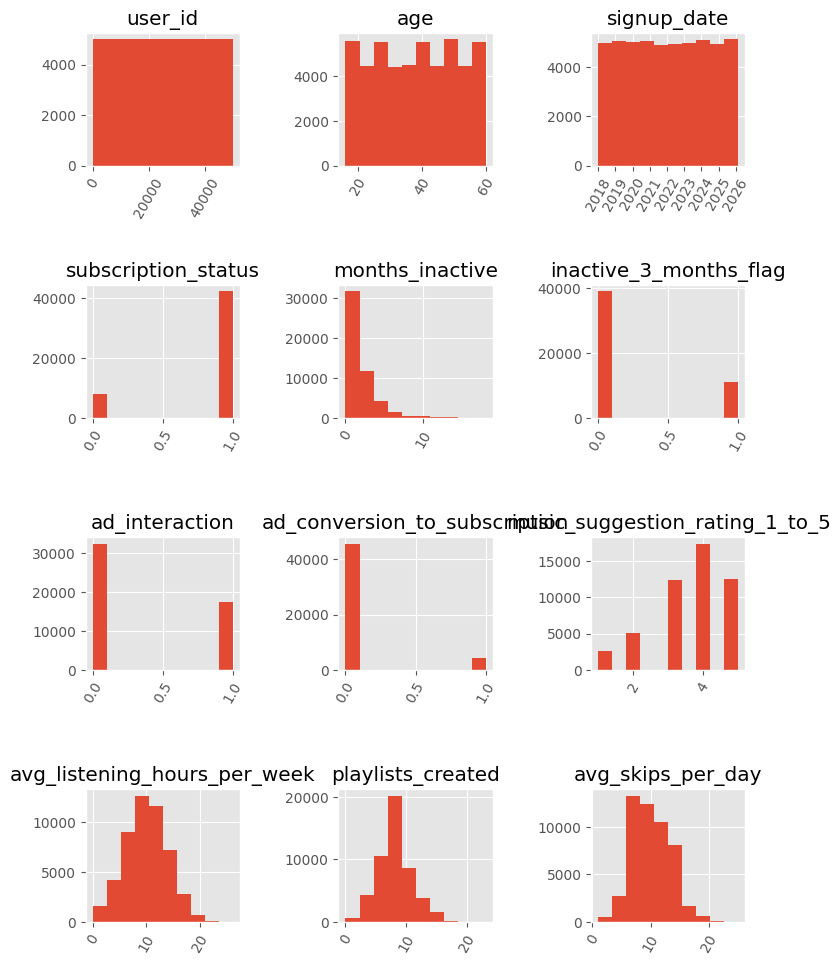

In [ ]:
num_col = df.select_dtypes(exclude=['object','str']).columns

plt.figure(figsize= (8,15))



for count, col in enumerate(num_col):
    plt.subplot(int(len(num_col) // 2), 3, count + 1)
    df[col].hist()
    plt.xticks(rotation = 60)
    plt.title(col)

plt.tight_layout(pad = 3)
plt.show()

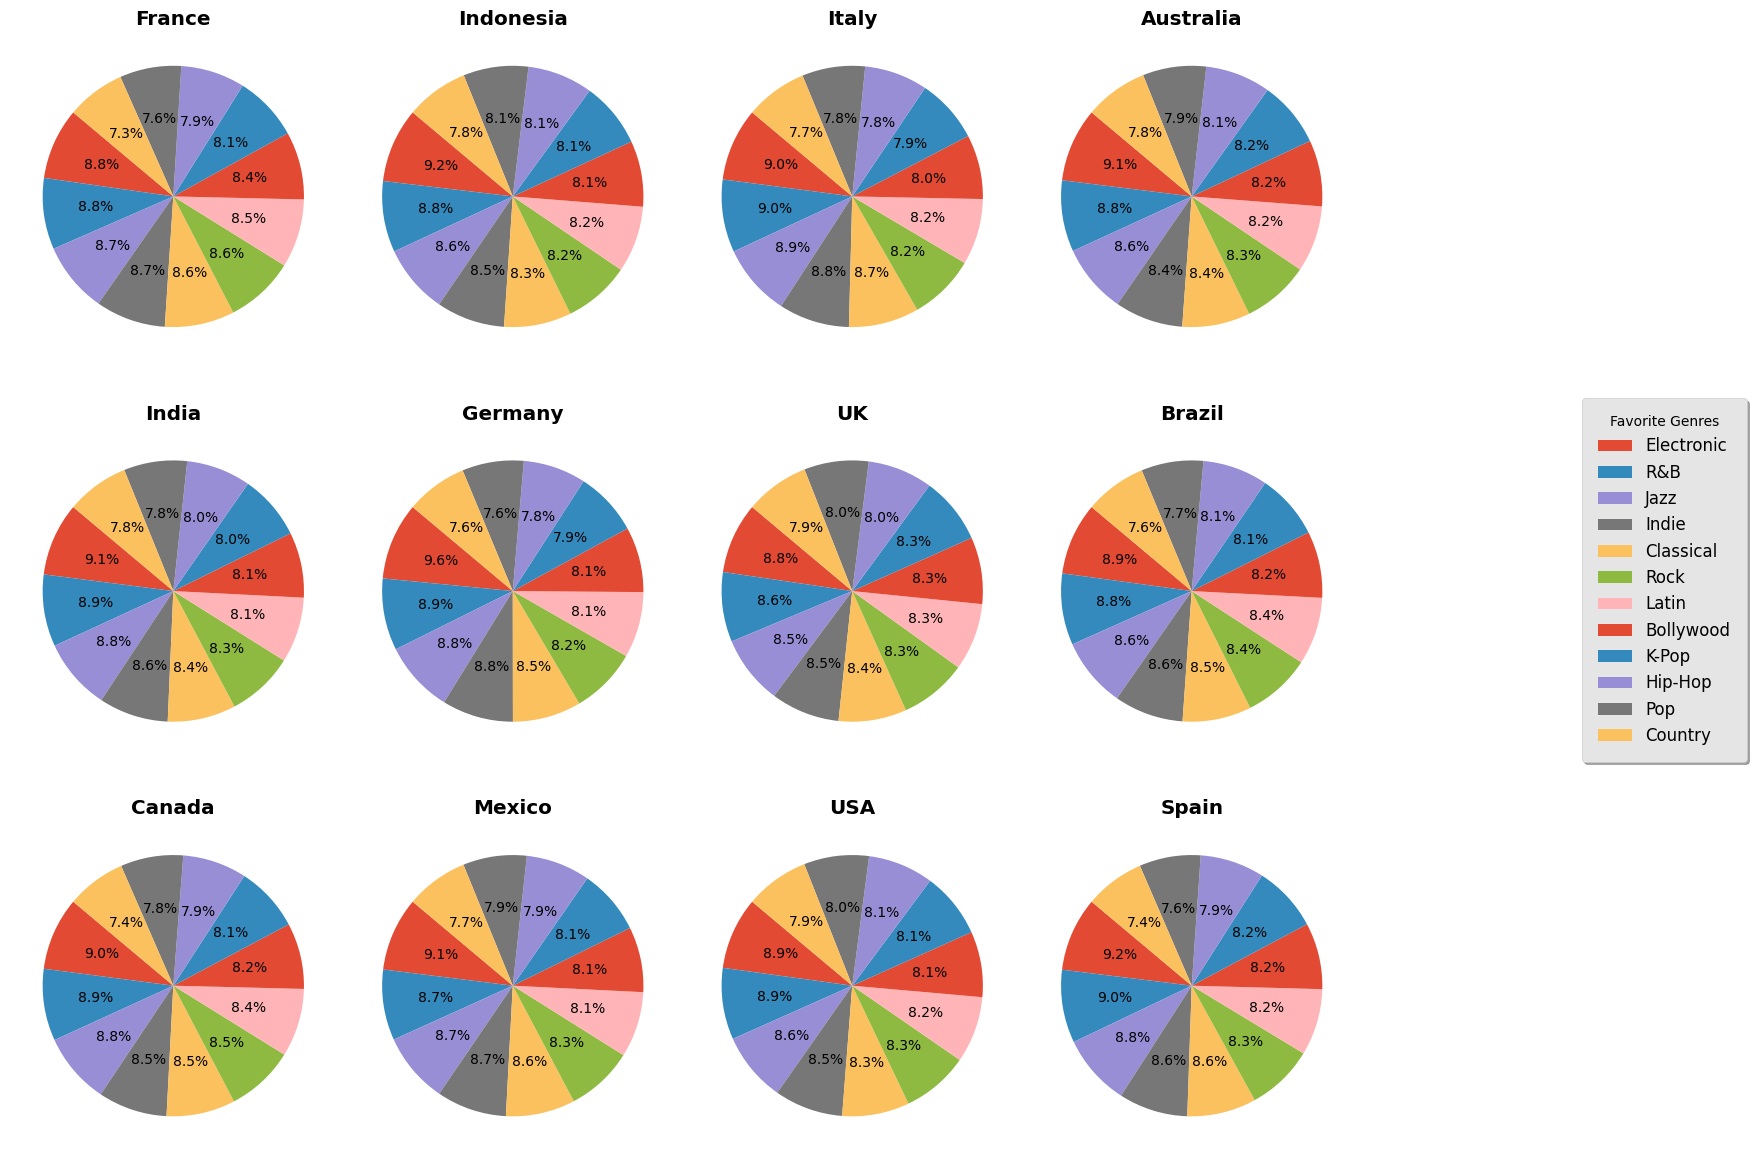

In [ ]:

import math

countries = df['country'].unique()
n_countries = len(countries)
cols = 4
rows = math.ceil(n_countries / cols)


fig = plt.figure(figsize=(16, rows * 4))

for count, country in enumerate(countries):
    df_country = df[df['country'] == country]
    ax = plt.subplot(rows, cols, count + 1)
    
    # Get the counts
    counts = df_country['favorite_genre'].value_counts()
    

    patches, texts, autotexts = ax.pie(counts, autopct='%1.1f%%', startangle=140)
    ax.set_title(country, fontweight='bold')


plt.figlegend(patches, counts.index, title="Favorite Genres", 
              loc='center right', bbox_to_anchor=(1.1, 0.5),
              fontsize=12, shadow=True, borderpad=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()

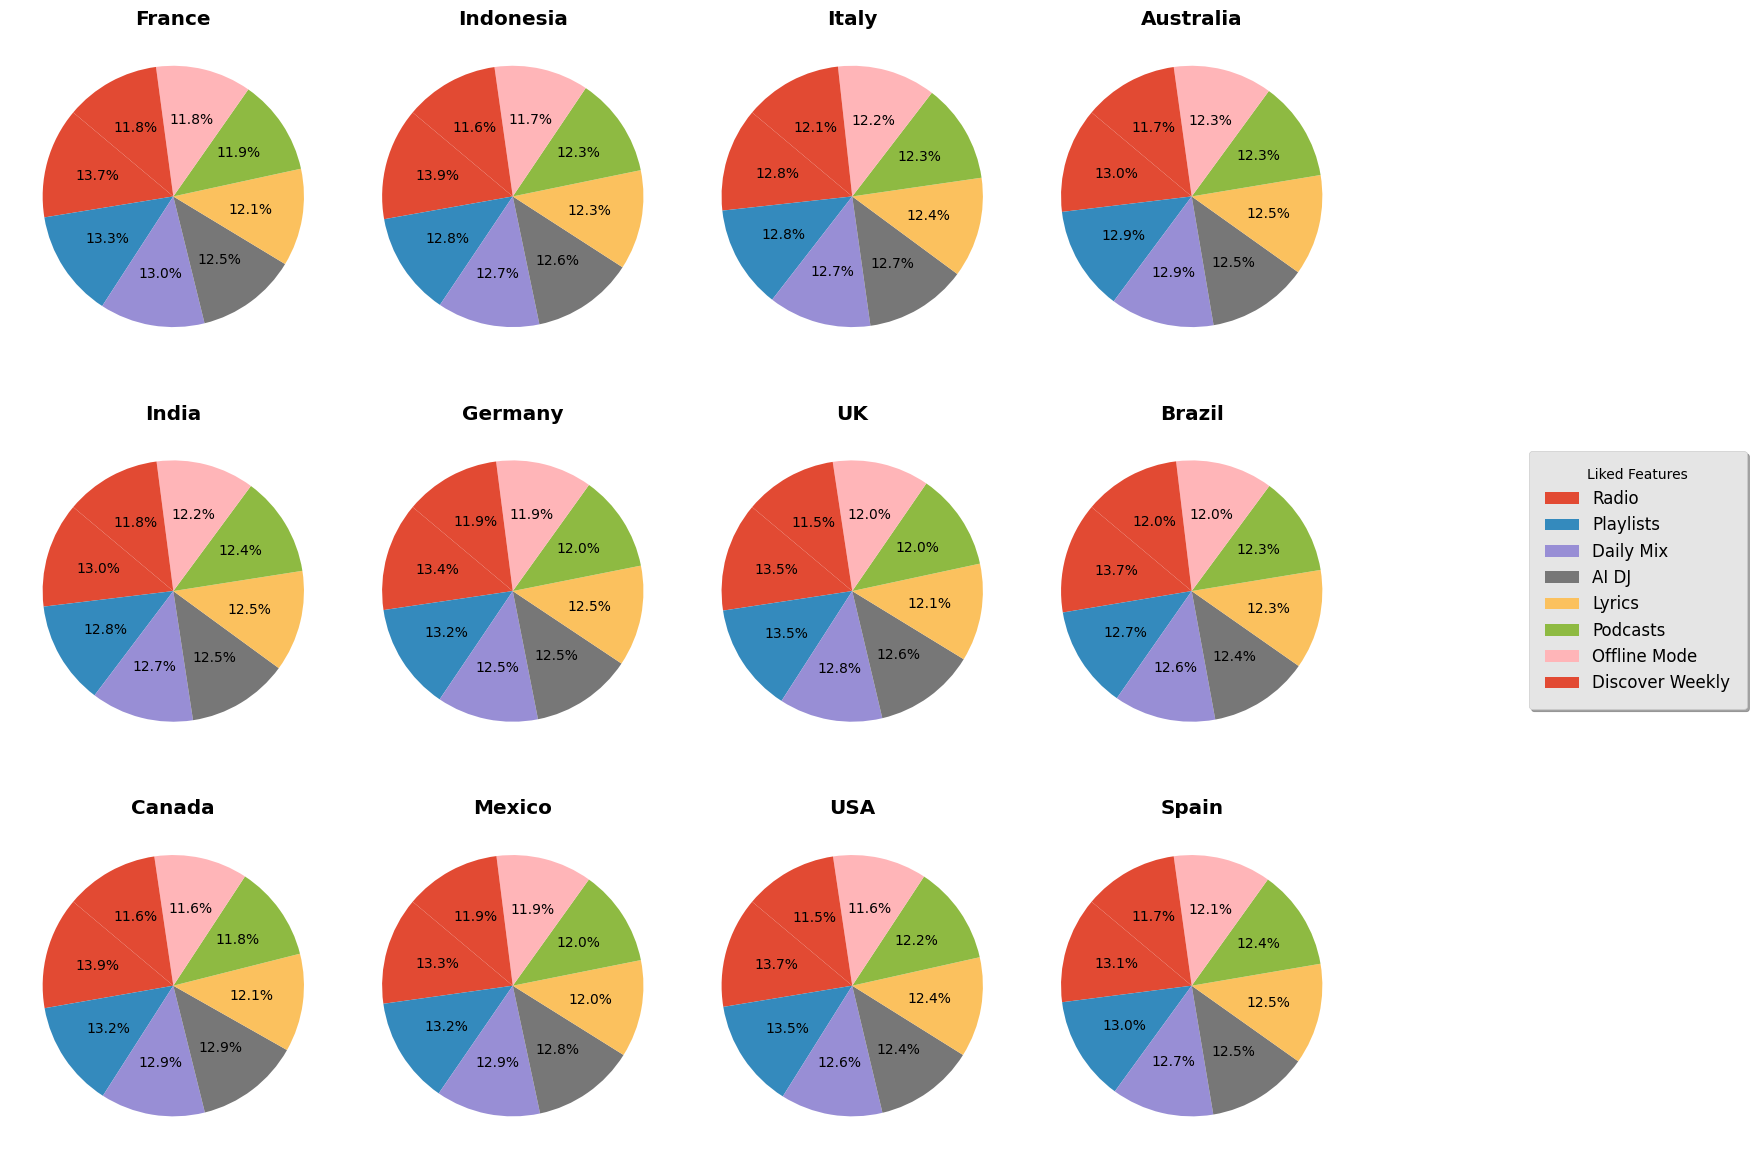

In [39]:
fig = plt.figure(figsize=(16, rows * 4))

for count, country in enumerate(countries):
    df_country = df[df['country'] == country]
    ax = plt.subplot(rows, cols, count + 1)
    
    # Get the counts
    counts = df_country['most_liked_feature'].value_counts()
    

    patches, texts, autotexts = ax.pie(counts, autopct='%1.1f%%', startangle=140)
    ax.set_title(country, fontweight='bold')


plt.figlegend(patches, counts.index, title="Liked Features", 
              loc='center right', bbox_to_anchor=(1.1, 0.5),
              fontsize=12, shadow=True, borderpad=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()

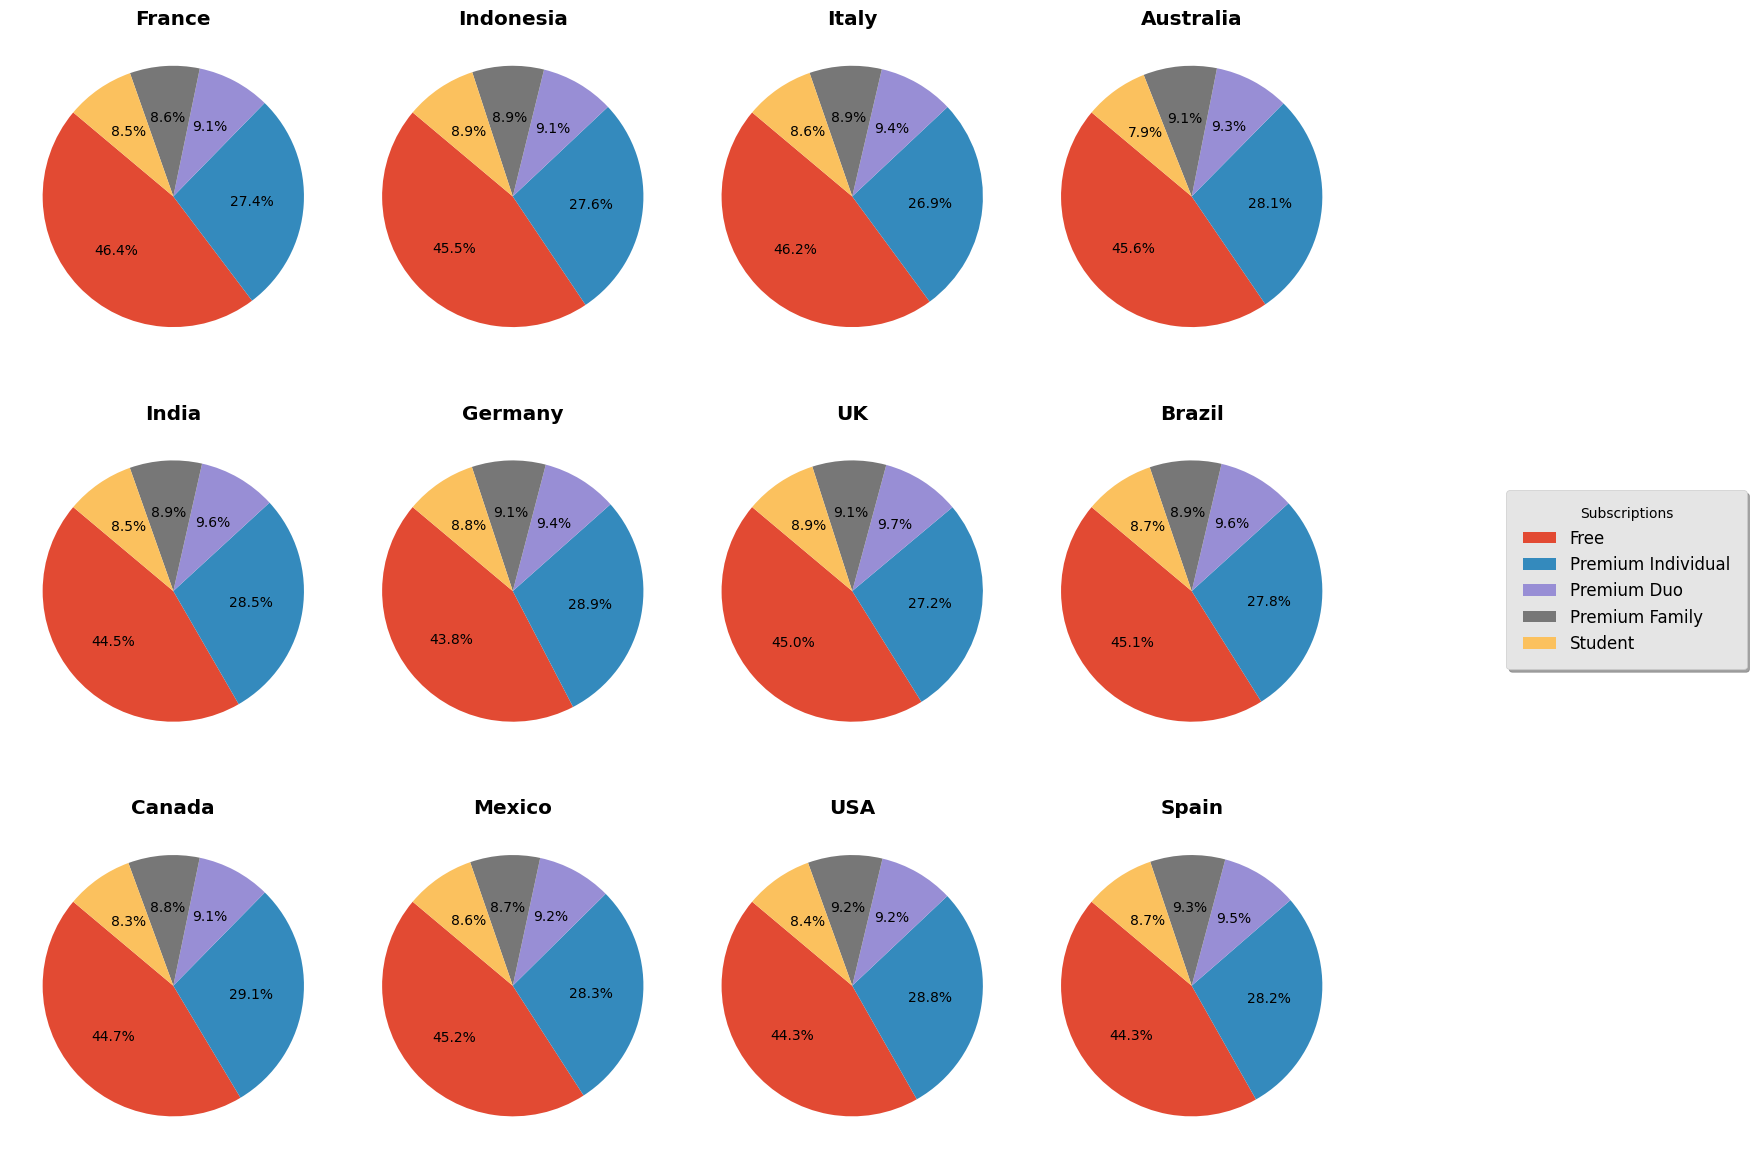

In [40]:
fig = plt.figure(figsize=(16, rows * 4))
for count, country in enumerate(countries):
    df_country = df[df['country'] == country]
    ax = plt.subplot(rows, cols, count + 1)
    
    # Get the counts
    counts = df_country['subscription_type'].value_counts()
    

    patches, texts, autotexts = ax.pie(counts, autopct='%1.1f%%', startangle=140)
    ax.set_title(country, fontweight='bold')


plt.figlegend(patches, counts.index, title="Subscriptions", 
              loc='center right', bbox_to_anchor=(1.1, 0.5),
              fontsize=12, shadow=True, borderpad=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()

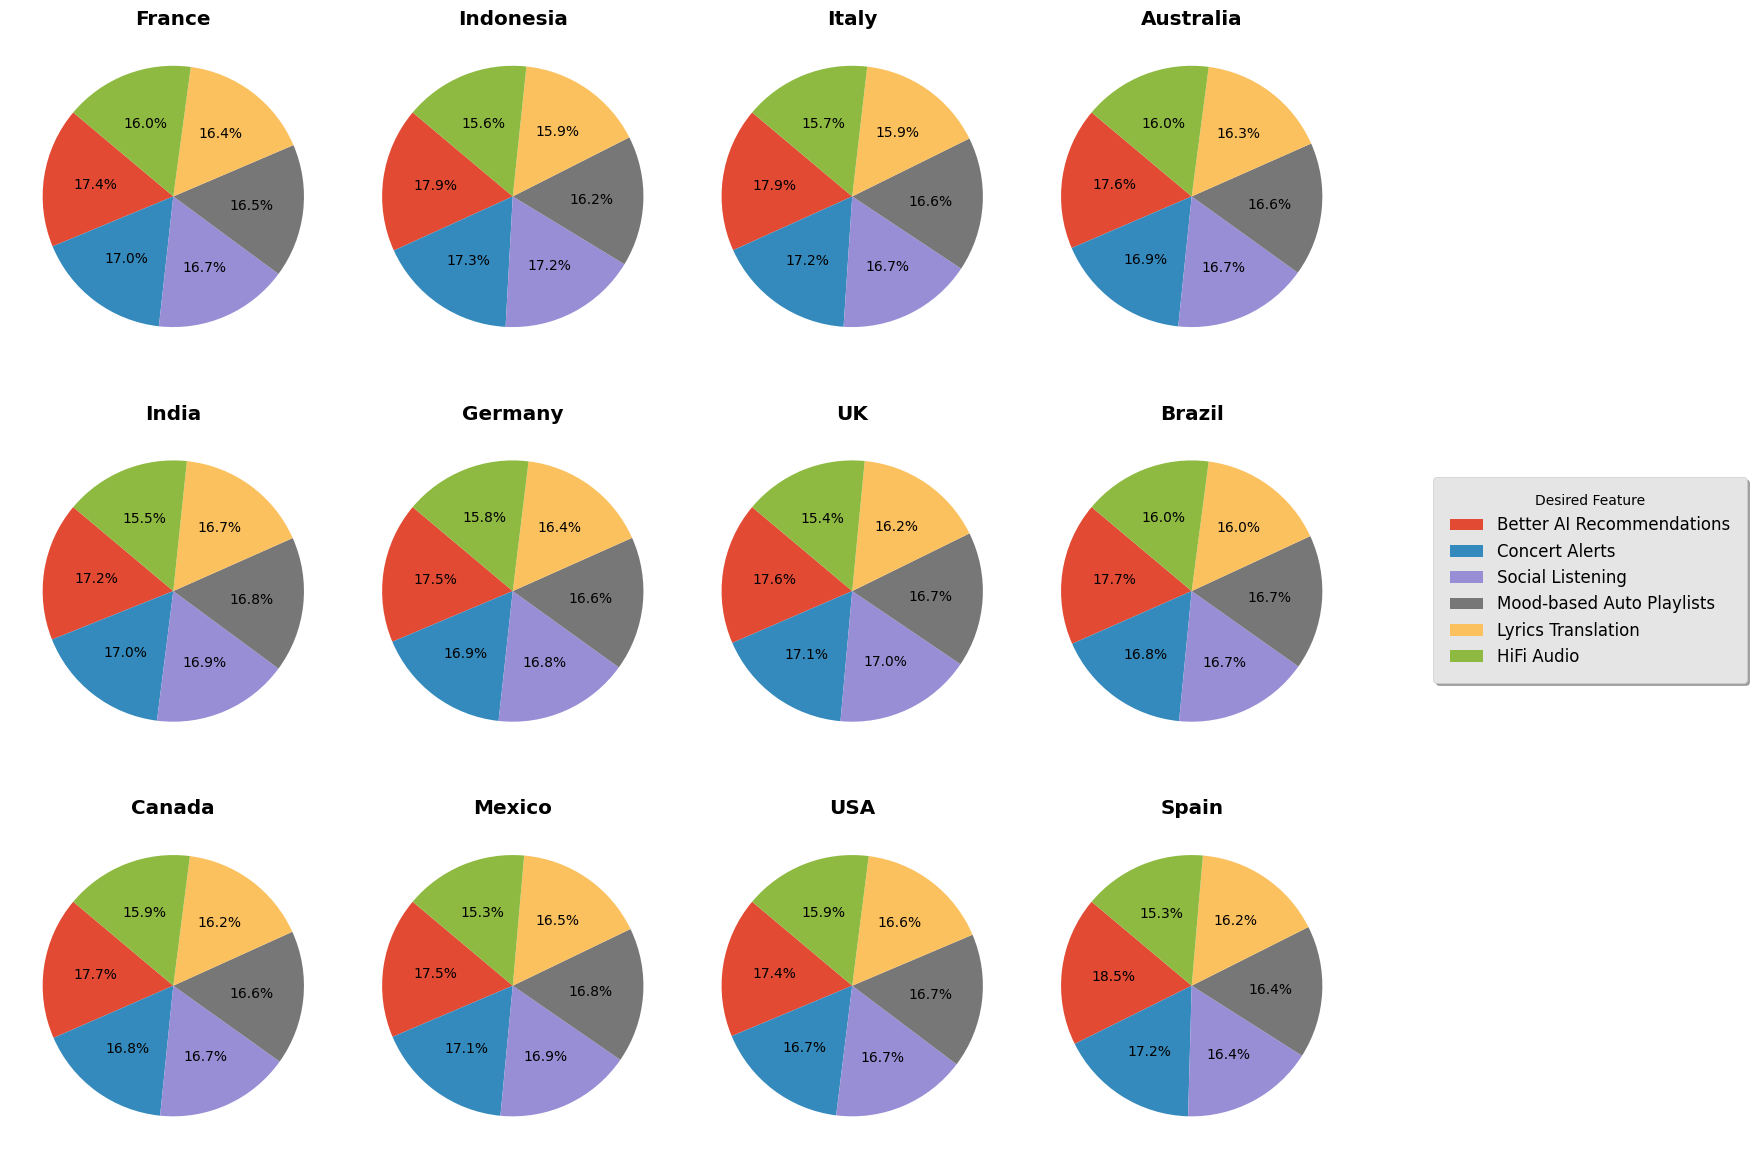

In [41]:
fig = plt.figure(figsize=(16, rows * 4))
for count, country in enumerate(countries):
    df_country = df[df['country'] == country]
    ax = plt.subplot(rows, cols, count + 1)
    
    # Get the counts
    counts = df_country['desired_future_feature'].value_counts()
    

    patches, texts, autotexts = ax.pie(counts, autopct='%1.1f%%', startangle=140)
    ax.set_title(country, fontweight='bold')


plt.figlegend(patches, counts.index, title="Desired Feature", 
              loc='center right', bbox_to_anchor=(1.1, 0.5),
              fontsize=12, shadow=True, borderpad=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()

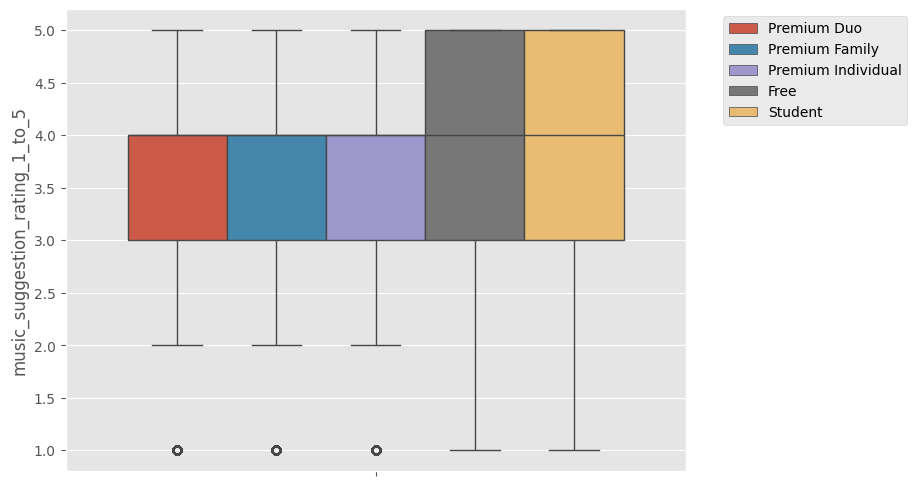

In [52]:

plt.figure(figsize= (8, 6))
sns.boxplot(df, y = 'music_suggestion_rating_1_to_5', hue = 'subscription_type')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

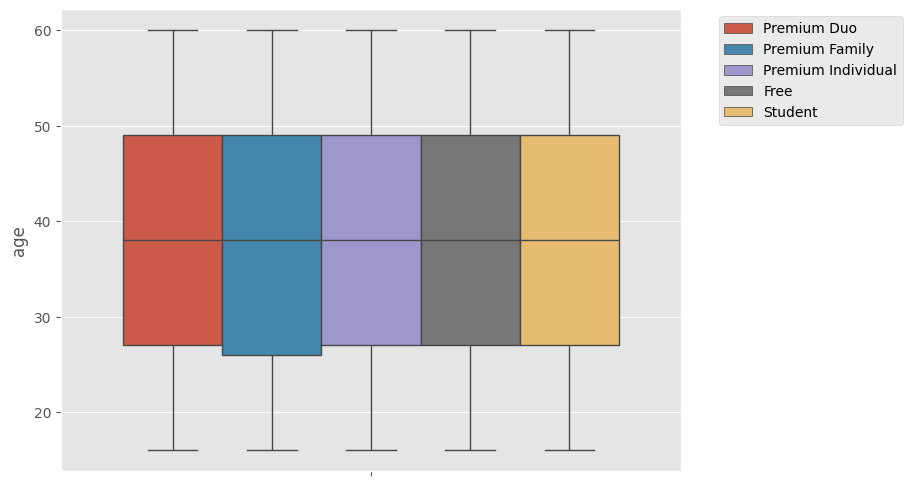

In [53]:

plt.figure(figsize= (8, 6))
sns.boxplot(df, y = 'age', hue = 'subscription_type')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

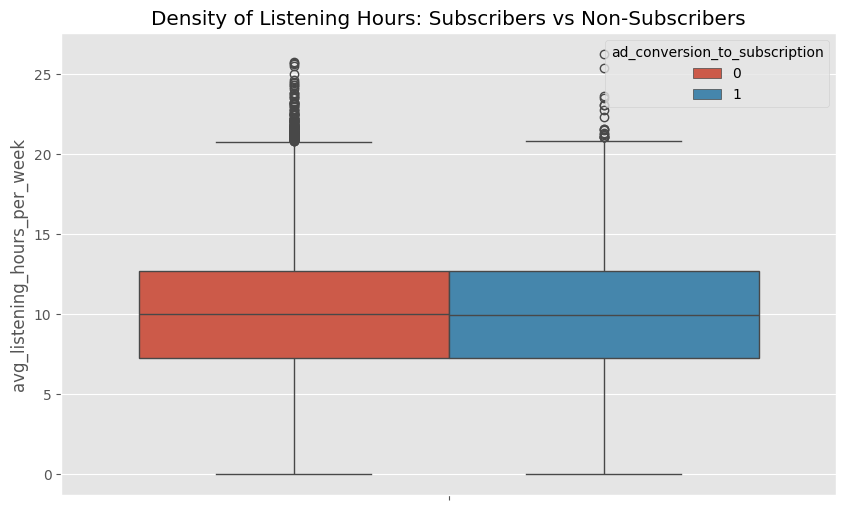

In [62]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, y='avg_listening_hours_per_week', 
            hue='ad_conversion_to_subscription', )

plt.title('Density of Listening Hours: Subscribers vs Non-Subscribers')
plt.show()

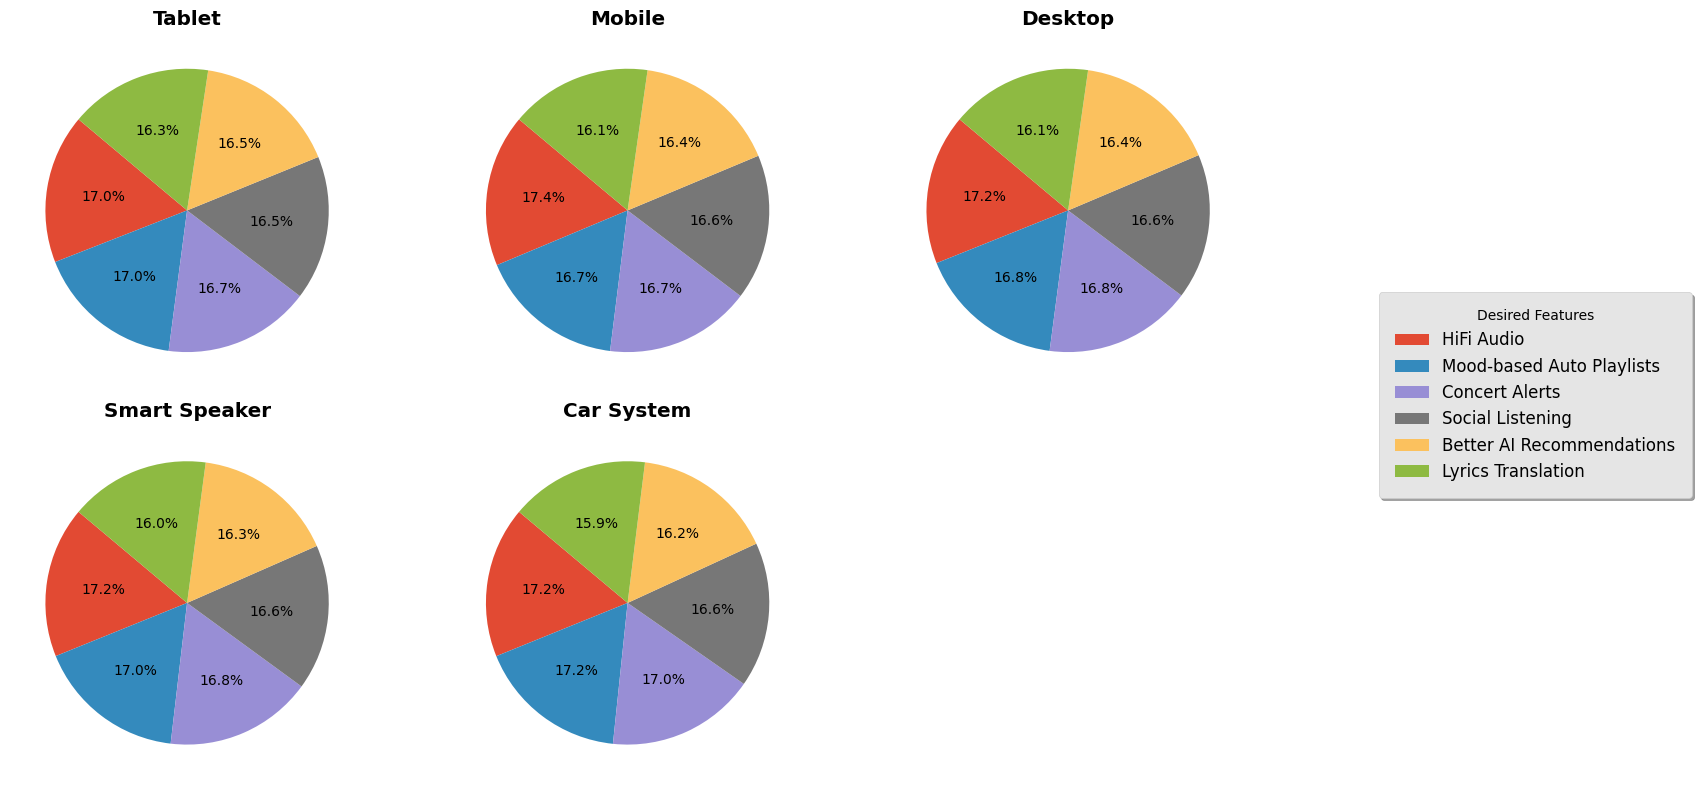

In [64]:
devices = df['primary_device'].unique()
n_devices = len(devices)
cols = 3
rows = math.ceil(n_devices / cols)


fig = plt.figure(figsize=(16, rows * 4))

for count, ele in enumerate(devices):
    df_devices = df[df['primary_device'] == ele]
    ax = plt.subplot(rows, cols, count + 1)
    
    # Get the counts
    counts = df_devices['desired_future_feature'].value_counts()
    

    patches, texts, autotexts = ax.pie(counts, autopct='%1.1f%%', startangle=140)
    ax.set_title(ele, fontweight='bold')


plt.figlegend(patches, counts.index, title="Desired Features", 
              loc='center right', bbox_to_anchor=(1.1, 0.5),
              fontsize=12, shadow=True, borderpad=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()